## 1. Importación de librerías

# Sistema de Recomendación de Productos
## Joyería Diana Laura — Análisis con Algoritmo Apriori

Este notebook implementa un sistema de recomendación basado en reglas de asociación (Apriori).
El objetivo es identificar qué productos se compran frecuentemente juntos para sugerir artículos
relacionados a los clientes durante su proceso de compra.

In [1]:
import os
import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import pickle
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
from dotenv import load_dotenv

load_dotenv()
print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


## 2. Conexión a la base de datos

In [2]:
DATABASE_URL = os.getenv('DATABASE_URL')

conn = psycopg2.connect(DATABASE_URL)
print('✅ Conexión exitosa a Supabase')

✅ Conexión exitosa a Supabase


## 3. Extracción de datos de ventas

In [3]:
query = """
    SELECT 
        v.id AS venta_id,
        v.folio,
        c.nombre AS cliente,
        dv.producto_nombre,
        v.fecha_creacion
    FROM ventas v
    JOIN clientes c ON c.id = v.cliente_id
    JOIN detalle_ventas dv ON dv.venta_id = v.id
    ORDER BY v.id
"""

df_raw = pd.read_sql(query, conn)
print(f'✅ Total de registros obtenidos: {len(df_raw)}')
df_raw.head(10)

C:\Users\uriel\AppData\Local\Temp\ipykernel_35408\466692411.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_raw = pd.read_sql(query, conn)


✅ Total de registros obtenidos: 40


,venta_id,folio,cliente,producto_nombre,fecha_creacion
0,442,DL-1784253204277,Marcos Uriel Hernandez Bautista,Aretes corazón doble plata,2026-07-17 01:53:24.247740
1,442,DL-1784253204277,Marcos Uriel Hernandez Bautista,Anillo plata solitario clásico,2026-07-17 01:53:24.247740
2,443,DL-1784253839316,Marcos Uriel Hernandez Bautista,Pulsera personalizada Día del Niño,2026-07-17 02:03:59.287587
3,443,DL-1784253839316,Marcos Uriel Hernandez Bautista,Aretitos plata corazón filigrana morado,2026-07-17 02:03:59.287587
4,444,DL-1784253990024,Marcos Uriel Hernandez Bautista,Anillo plata piedra corazón rosa,2026-07-17 02:06:29.996708
5,444,DL-1784253990024,Marcos Uriel Hernandez Bautista,Aretitos plata gota filigrana con perla,2026-07-17 02:06:29.996708
6,445,DL-1784254117847,Marcos Uriel Hernandez Bautista,Aretes plata ley .925 cristal azul y corazón f...,2026-07-17 02:08:37.820498
7,445,DL-1784254117847,Marcos Uriel Hernandez Bautista,Esclava personalizada Día del Padre,2026-07-17 02:08:37.820498
8,446,DL-1784254222960,Marcos Uriel Hernandez Bautista,Aretes corazón doble plata,2026-07-17 02:10:22.933768
9,446,DL-1784254222960,Marcos Uriel Hernandez Bautista,Anillo dorado diseño floral con circonias,2026-07-17 02:10:22.933768


## 4. Exploración de datos

In [4]:
print('=== RESUMEN DE DATOS ===')
print(f'Total de ventas (tickets): {df_raw["venta_id"].nunique()}')
print(f'Total de clientes: {df_raw["cliente"].nunique()}')
print(f'Total de productos distintos: {df_raw["producto_nombre"].nunique()}')
print()
print('=== CLIENTES ===')
print(df_raw['cliente'].value_counts())
print()
print('=== PRODUCTOS MÁS FRECUENTES ===')
print(df_raw['producto_nombre'].value_counts())

=== RESUMEN DE DATOS ===
Total de ventas (tickets): 18
Total de clientes: 4
Total de productos distintos: 15

=== CLIENTES ===
cliente
Marcos Uriel Hernandez Bautista    12
Valentina Bautista Hernandez       12
Blanca Hernandez Bautista           9
Diana Laura Hernandez Martinez      7
Name: count, dtype: int64

=== PRODUCTOS MÁS FRECUENTES ===
producto_nombre
Aretes corazón doble plata                                5
Pulsera personalizada Día del Niño                        5
Aretitos plata corazón filigrana morado                   5
Aretes plata ley .925 cristal azul y corazón filigrana    4
Esclava personalizada Día del Padre                       4
Anillo plata solitario clásico                            3
Aretitos plata gota filigrana con perla                   3
Anillo plata piedra corazón rosa                          2
Anillo dorado diseño floral con circonias                 2
Anillo plata ley .925 corazón amatista                    2
Esclava laminado de oro figaro       

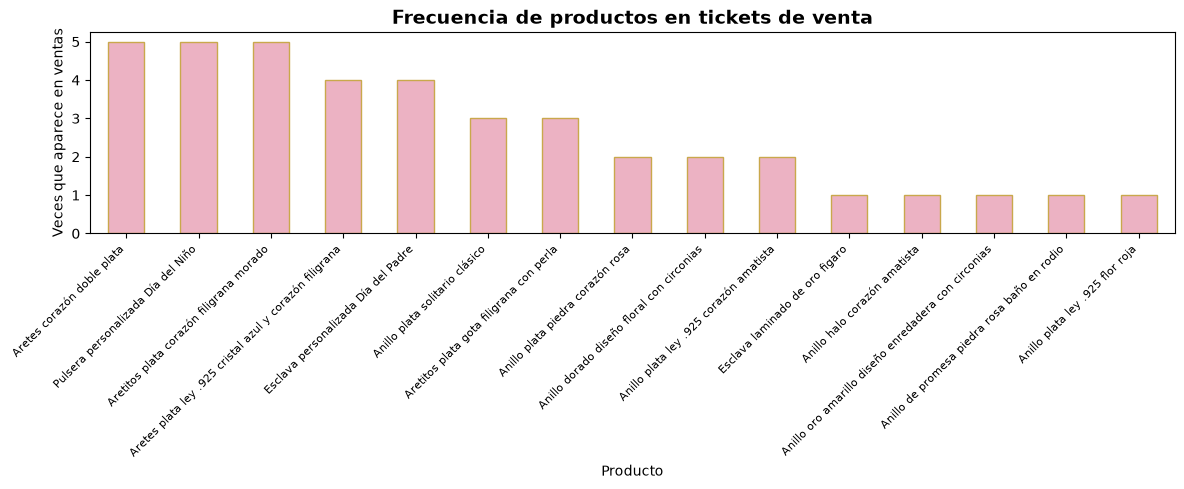

In [5]:
# Productos más vendidos
fig, ax = plt.subplots(figsize=(12, 5))
conteo = df_raw['producto_nombre'].value_counts()
conteo.plot(kind='bar', ax=ax, color='#ECB2C3', edgecolor='#c9a84c')
ax.set_title('Frecuencia de productos en tickets de venta', fontsize=14, fontweight='bold')
ax.set_xlabel('Producto')
ax.set_ylabel('Veces que aparece en ventas')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

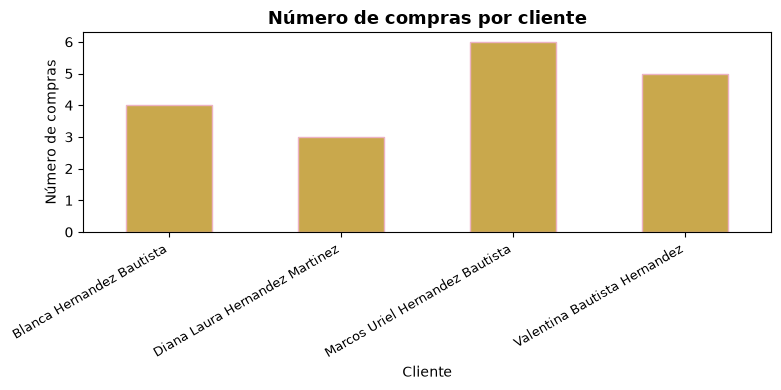

In [6]:
# Ventas por cliente
ventas_por_cliente = df_raw.groupby('cliente')['venta_id'].nunique()
fig, ax = plt.subplots(figsize=(8, 4))
ventas_por_cliente.plot(kind='bar', ax=ax, color='#c9a84c', edgecolor='#ECB2C3')
ax.set_title('Número de compras por cliente', fontsize=13, fontweight='bold')
ax.set_xlabel('Cliente')
ax.set_ylabel('Número de compras')
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

## 5. Preparación de tickets para el modelo

In [7]:
# Agrupar por venta_id para obtener los tickets
tickets = df_raw.groupby('venta_id')['producto_nombre'].apply(list).tolist()

print(f'Total de tickets: {len(tickets)}')
print()
print('Ejemplo de tickets:')
for i, t in enumerate(tickets[:5]):
    print(f'  Ticket {i+1}: {t}')

Total de tickets: 18

Ejemplo de tickets:
  Ticket 1: ['Aretes corazón doble plata', 'Anillo plata solitario clásico']
  Ticket 2: ['Pulsera personalizada Día del Niño', 'Aretitos plata corazón filigrana morado']
  Ticket 3: ['Anillo plata piedra corazón rosa', 'Aretitos plata gota filigrana con perla']
  Ticket 4: ['Aretes plata ley .925 cristal azul y corazón filigrana', 'Esclava personalizada Día del Padre']
  Ticket 5: ['Aretes corazón doble plata', 'Anillo dorado diseño floral con circonias']


In [8]:
# Codificación de transacciones
te = TransactionEncoder()
te_array = te.fit(tickets).transform(tickets)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

print(f'Dimensiones de la matriz: {df_encoded.shape}')
print(f'Productos (columnas): {list(df_encoded.columns)}')
df_encoded.head()

Dimensiones de la matriz: (18, 15)
Productos (columnas): ['Anillo de promesa piedra rosa baño en rodio', 'Anillo dorado diseño floral con circonias', 'Anillo halo corazón amatista', 'Anillo oro amarillo diseño enredadera con circonias', 'Anillo plata ley .925 corazón amatista', 'Anillo plata ley .925 flor roja', 'Anillo plata piedra corazón rosa', 'Anillo plata solitario clásico', 'Aretes corazón doble plata', 'Aretes plata ley .925 cristal azul y corazón filigrana', 'Aretitos plata corazón filigrana morado', 'Aretitos plata gota filigrana con perla', 'Esclava laminado de oro figaro', 'Esclava personalizada Día del Padre', 'Pulsera personalizada Día del Niño']


,Anillo de promesa piedra rosa baño en rodio,Anillo dorado diseño floral con circonias,Anillo halo corazón amatista,Anillo oro amarillo diseño enredadera con circonias,Anillo plata ley .925 corazón amatista,Anillo plata ley .925 flor roja,Anillo plata piedra corazón rosa,Anillo plata solitario clásico,Aretes corazón doble plata,Aretes plata ley .925 cristal azul y corazón filigrana,Aretitos plata corazón filigrana morado,Aretitos plata gota filigrana con perla,Esclava laminado de oro figaro,Esclava personalizada Día del Padre,Pulsera personalizada Día del Niño
0,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True
2,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False
4,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False


## 6. Entrenamiento del modelo Apriori

In [9]:
# Encontrar itemsets frecuentes
frequent_itemsets = apriori(df_encoded, min_support=0.1, use_colnames=True)
frequent_itemsets['longitud'] = frequent_itemsets['itemsets'].apply(len)

print(f'Total de itemsets frecuentes encontrados: {len(frequent_itemsets)}')
frequent_itemsets.sort_values('support', ascending=False)

Total de itemsets frecuentes encontrados: 12


,support,itemsets,longitud
6,0.277778,frozenset({Aretitos plata corazón filigrana mo...,1
9,0.277778,frozenset({Pulsera personalizada Día del Niño}),1
4,0.277778,frozenset({Aretes corazón doble plata}),1
5,0.222222,frozenset({Aretes plata ley .925 cristal azul ...,1
8,0.222222,frozenset({Esclava personalizada Día del Padre}),1
7,0.166667,frozenset({Aretitos plata gota filigrana con p...,1
3,0.166667,frozenset({Anillo plata solitario clásico}),1
0,0.111111,frozenset({Anillo dorado diseño floral con cir...,1
2,0.111111,frozenset({Anillo plata piedra corazón rosa}),1
1,0.111111,frozenset({Anillo plata ley .925 corazón amati...,1


In [10]:
# Generar reglas de asociación
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.1, num_itemsets=len(frequent_itemsets))
rules = rules.sort_values('confidence', ascending=False)

print(f'Total de reglas generadas: {len(rules)}')
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

Total de reglas generadas: 4


,antecedents,consequents,support,confidence,lift
0,frozenset({Esclava personalizada Día del Padre}),frozenset({Aretes corazón doble plata}),0.111111,0.5,1.80
1,frozenset({Aretes corazón doble plata}),frozenset({Esclava personalizada Día del Padre}),0.111111,0.4,1.80
2,frozenset({Pulsera personalizada Día del Niño}),frozenset({Aretitos plata corazón filigrana mo...,0.111111,0.4,1.44
3,frozenset({Aretitos plata corazón filigrana mo...,frozenset({Pulsera personalizada Día del Niño}),0.111111,0.4,1.44


## 7. Visualización de reglas

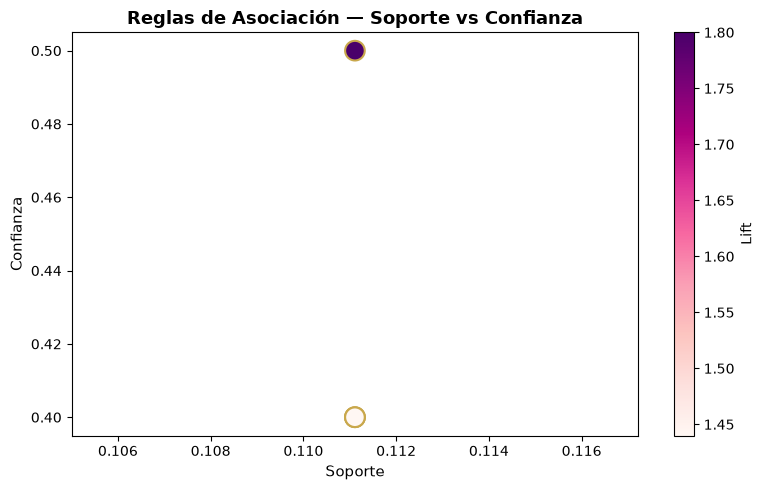

In [11]:
# Gráfica de soporte vs confianza
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(
    rules['support'],
    rules['confidence'],
    c=rules['lift'],
    cmap='RdPu',
    s=200,
    edgecolors='#c9a84c',
    linewidths=1.5
)
plt.colorbar(scatter, label='Lift')
ax.set_xlabel('Soporte', fontsize=11)
ax.set_ylabel('Confianza', fontsize=11)
ax.set_title('Reglas de Asociación — Soporte vs Confianza', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# Mostrar reglas en formato legible
print('=== REGLAS DE ASOCIACIÓN ENCONTRADAS ===')
print()
for _, row in rules.iterrows():
    antecedente = list(row['antecedents'])[0]
    consecuente = list(row['consequents'])[0]
    print(f'Si compra: "{antecedente}"')
    print(f'  → También suele llevar: "{consecuente}"')
    print(f'     Confianza: {round(row["confidence"]*100, 1)}%  |  Lift: {round(row["lift"], 2)}')
    print()

=== REGLAS DE ASOCIACIÓN ENCONTRADAS ===

Si compra: "Esclava personalizada Día del Padre"
  → También suele llevar: "Aretes corazón doble plata"
     Confianza: 50.0%  |  Lift: 1.8

Si compra: "Aretes corazón doble plata"
  → También suele llevar: "Esclava personalizada Día del Padre"
     Confianza: 40.0%  |  Lift: 1.8

Si compra: "Pulsera personalizada Día del Niño"
  → También suele llevar: "Aretitos plata corazón filigrana morado"
     Confianza: 40.0%  |  Lift: 1.44

Si compra: "Aretitos plata corazón filigrana morado"
  → También suele llevar: "Pulsera personalizada Día del Niño"
     Confianza: 40.0%  |  Lift: 1.44



## 8. Prueba del sistema de recomendación

In [13]:
def recomendar(productos_carrito, rules, top_n=3):
    recomendaciones = {}
    for producto in productos_carrito:
        filtro = rules[rules['antecedents'].apply(lambda x: producto in x)]
        for _, row in filtro.iterrows():
            for rec in row['consequents']:
                if rec not in productos_carrito:
                    if rec not in recomendaciones:
                        recomendaciones[rec] = 0
                    recomendaciones[rec] += row['confidence']
    
    ordenadas = sorted(recomendaciones.items(), key=lambda x: x[1], reverse=True)
    return [r[0] for r in ordenadas[:top_n]]

# Prueba 1
carrito = ['Aretes corazón doble plata']
recs = recomendar(carrito, rules)
print(f'Carrito: {carrito}')
print(f'Recomendaciones: {recs}')
print()

# Prueba 2
carrito2 = ['Pulsera personalizada Día del Niño']
recs2 = recomendar(carrito2, rules)
print(f'Carrito: {carrito2}')
print(f'Recomendaciones: {recs2}')

Carrito: ['Aretes corazón doble plata']
Recomendaciones: ['Esclava personalizada Día del Padre']

Carrito: ['Pulsera personalizada Día del Niño']
Recomendaciones: ['Aretitos plata corazón filigrana morado']


## 9. Guardar el modelo

In [14]:
modelo = {
    'rules': rules,
    'te': te,
    'frequent_itemsets': frequent_itemsets
}

with open('modelo_recomendacion.pkl', 'wb') as f:
    pickle.dump(modelo, f)

print('✅ Modelo guardado como modelo_recomendacion.pkl')

✅ Modelo guardado como modelo_recomendacion.pkl


## 10. Conclusiones

El sistema de recomendación basado en el algoritmo Apriori fue implementado exitosamente para Joyería Diana Laura.

**Resultados obtenidos:**
- Se analizaron los tickets de venta históricos de la plataforma
- El modelo identificó patrones de compra entre los productos del catálogo
- Se generaron reglas de asociación con métricas de soporte, confianza y lift

**Interpretación de métricas:**
- **Soporte:** frecuencia con la que aparece la combinación en el total de tickets
- **Confianza:** probabilidad de que al comprar el producto A también se compre el B
- **Lift > 1:** indica que la relación entre productos no es aleatoria, existe una asociación real

**Siguiente paso:** El modelo fue exportado como `modelo_recomendacion.pkl` y será consumido por el microservicio Flask para integrarse con la plataforma web de Joyería Diana Laura.